In [9]:
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
import random




Found 8435 files belonging to 4 classes.
Using 6748 files for training.
Found 8435 files belonging to 4 classes.
Using 1687 files for validation.
Class names: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


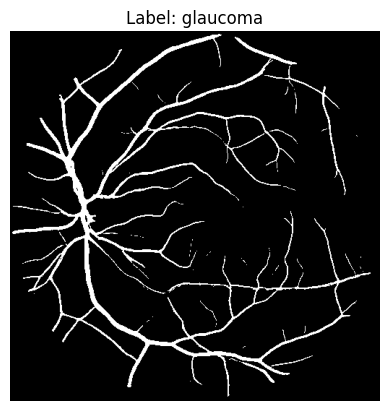

In [11]:

# Load the dataset
img_size = (512, 512)
batch_size = 32
seed = 42

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "CombinedData",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,
    validation_split=0.2, 
    subset="training"  
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "CombinedData",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,  
    validation_split=0.2, 
    subset="validation" 
)

# Show class names
print("Class names:", train_data.class_names)


def display_image(image, label):
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(f"Label: {train_data.class_names[label]}")
    plt.axis('off')
    plt.show()


image, label = next(iter(train_data))
display_image(image[0], label[0])

In [5]:
# Count the number of samples in each class
class_counts = {class_name: 0 for class_name in train_data.class_names}

for image, label in train_data:
    for l in label.numpy():
        class_counts[train_data.class_names[l]] += 1

class_counts

{'cataract': 834, 'diabetic_retinopathy': 881, 'glaucoma': 806, 'normal': 853}

In [6]:

def cnn_model(NUMBER_OF_CLASSES, input_shape=(256, 256, 3)):
    model = models.Sequential()

    # First Convolutional Block
    model.add(layers.Conv2D(16, (3, 3), strides=2, padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2, 2), strides=2))

    # Second Convolutional Block
    model.add(layers.Conv2D(32, (3, 3), strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2, 2), strides=2))

    # Third Convolutional Block
    model.add(layers.Conv2D(64, (3, 3), strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2, 2), strides=2))

    # Flatten and Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(NUMBER_OF_CLASSES, activation='softmax'))  # Softmax for multi-class classification

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # Suitable for integer labels
                  metrics=['acc'])

    return model


In [7]:

input_shape = (256, 256, 3) 
num_classes = len(train_data.class_names)

cnn_model = cnn_model(num_classes, input_shape)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = cnn_model.fit(train_data, validation_data=val_data, epochs=30, callbacks=[early_stopping])
cnn_model.summary()

c:\Users\rajku\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - acc: 0.5006 - loss: 1.3320 - val_acc: 0.6975 - val_loss: 0.7686
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 174ms/step - acc: 0.7077 - loss: 0.7100 - val_acc: 0.7746 - val_loss: 0.5718
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 174ms/step - acc: 0.7491 - loss: 0.6098 - val_acc: 0.7936 - val_loss: 0.5242
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - acc: 0.7779 - loss: 0.5508 - val_acc: 0.8434 - val_loss: 0.3939
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - acc: 0.7959 - loss: 0.4926 - val_acc: 0.6856 - val_loss: 0.8542
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - acc: 0.8185 - loss: 0.4560 - val_acc: 0.8470 - val_loss: 0.4040
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 19s 175ms/step - acc: 0.8022 - loss: 0.4740 - val_acc: 0.8327 - val_loss: 0.3928
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - acc: 0.8297 - loss: 0.4221 - val_acc: 0.8529 - val_loss: 0.3710
Epoch 9/30
106/106 ━━━━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 466,798 (1.78 MB)

 Trainable params: 155,524 (607.52 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 311,050 (1.19 MB)

In [8]:
#confusion matrix


y_pred = []
y_true = []

for x, y in val_data:
    y_pred.extend(cnn_model.predict(x).argmax(axis=1))
    y_true.extend(y.numpy())
    
cm = confusion_matrix(np.array(y_true), np.array(y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/st

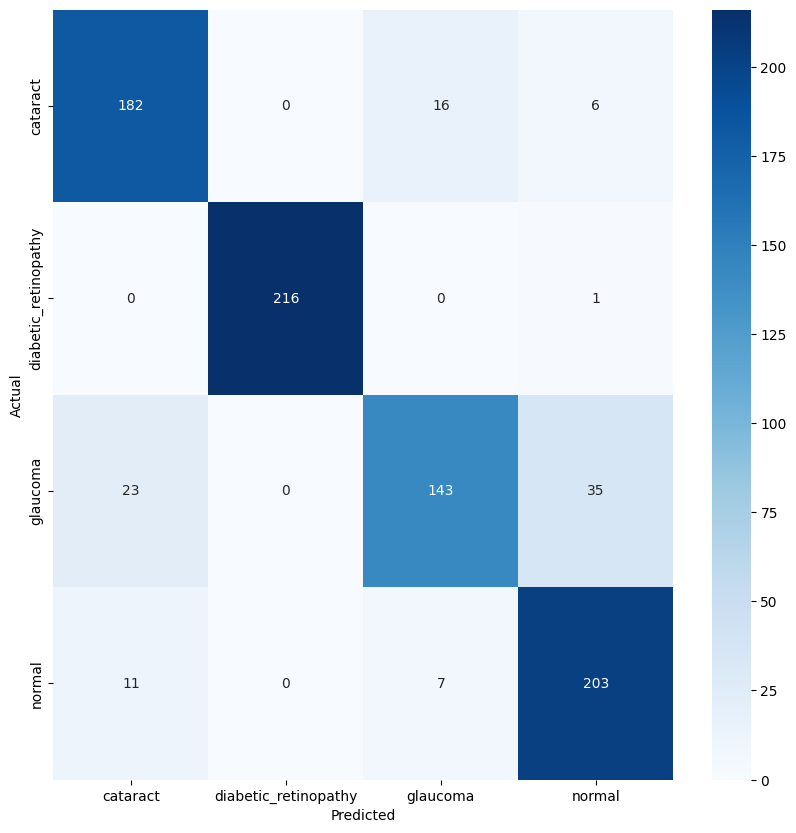

In [9]:
#plot confusion matrix


plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=train_data.class_names, yticklabels=train_data.class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
# save the model
cnn_model.save("D:/Retinal Vessel Segmentation/model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


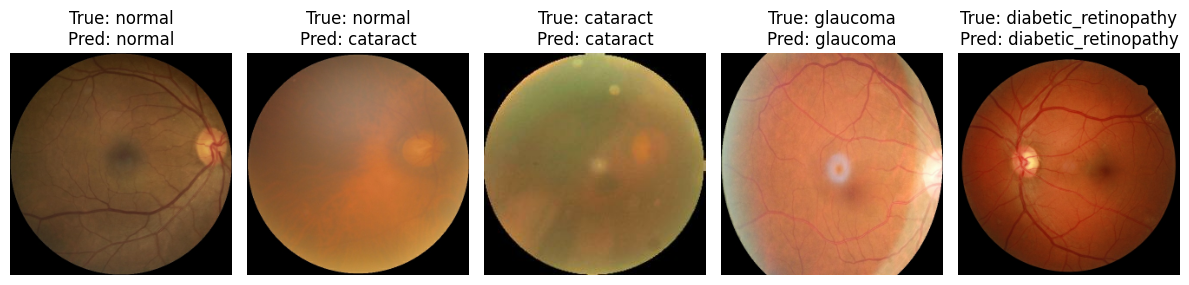

In [11]:


image, label = next(iter(val_data))


predictions = cnn_model.predict(image)
predicted_labels = np.argmax(predictions, axis=1)
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(12, 3))

for i in range(num_images):
    idx = random.randint(0, len(image) - 1)
    axes[i].imshow(image[idx].numpy().astype("uint8"))
    true_label = label[idx].numpy()
    predicted_label = predicted_labels[idx]
    axes[i].set_title(f"True: {train_data.class_names[true_label]}\nPred: {train_data.class_names[predicted_label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np
import os
import cv2

# Paths for input data
base_path = "CombinedData"

categories = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
img_size = (512, 512)
batch_size = 32
num_classes = len(categories)

# Load and preprocess images
def load_images_and_labels(base_path, categories):
    images = []
    labels = []
    for label, category in enumerate(categories):
        retinal_images_path = os.path.join(base_path, category, "retinal_images")
        masked_images_path = os.path.join(base_path, category, "masked_images")
        
        retinal_files = os.listdir(retinal_images_path)
        masked_files = os.listdir(masked_images_path)
        
        for file_name in retinal_files:
            retinal_path = os.path.join(retinal_images_path, file_name)
            masked_path = os.path.join(masked_images_path, file_name)
            
            if os.path.exists(retinal_path) and os.path.exists(masked_path):
                retinal_img = cv2.imread(retinal_path)
                masked_img = cv2.imread(masked_path)

                if retinal_img is not None and masked_img is not None:
                    retinal_img = cv2.resize(retinal_img, img_size) / 255.0
                    masked_img = cv2.resize(masked_img, img_size) / 255.0
                    combined_img = np.concatenate([retinal_img, masked_img], axis=-1)

                    images.append(combined_img)
                    labels.append(label)

    return np.array(images), np.array(labels)

# Load data
combined_images, labels = load_images_and_labels(base_path, categories)

# Split data
X_train, X_val, y_train, y_val = train_test_split(combined_images, labels, test_size=0.2, random_state=42)

# Build model
def cnn_model(NUMBER_OF_CLASSES, input_shape=(512, 512, 6)):
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(16, (3, 3), strides=2, padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPooling2D((2, 2), strides=2))

    # Second Convolutional Block
    model.add(Conv2D(32, (3, 3), strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPooling2D((2, 2), strides=2))

    # Third Convolutional Block
    model.add(Conv2D(64, (3, 3), strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(MaxPooling2D((2, 2), strides=2))

    # Flatten and Dense Layers
    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(NUMBER_OF_CLASSES, activation='softmax'))  # Softmax for multi-class classification

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # Suitable for integer labels
                  metrics=['acc'])

    return model

model = cnn_model(num_classes)

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = datagen.flow(X_train, y_train, batch_size=batch_size)

# Train the model
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=30,
)

# Save the model
model.save("retinal_disease_classifier.h5")

print("Model training completed and saved.")


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.3896 - loss: 2.2760 - val_accuracy: 0.4634 - val_loss: 0.8356
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.6970 - loss: 1.4576 - val_accuracy: 0.8780 - val_loss: 0.7124
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6355 - loss: 1.2270 - val_accuracy: 0.5366 - val_loss: 0.6906
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7228 - loss: 1.0978 - val_accuracy: 0.5366 - val_loss: 0.6638
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7503 - loss: 0.7284 - val_accuracy: 0.5366 - val_loss: 0.7436
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.7789 - loss: 0.6165 - val_accuracy: 0.5366 - val_loss: 0.7478
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.7650 - loss: 0.5287 - val_accuracy: 0.5366 - val_loss: 0.8618
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.7489 - loss: 0.4918 - val_accuracy: 0.5366 - val_loss: 0.8699
Epoch 9/

Model training completed and saved.


Data Loading Complete.
Number of classes: 4


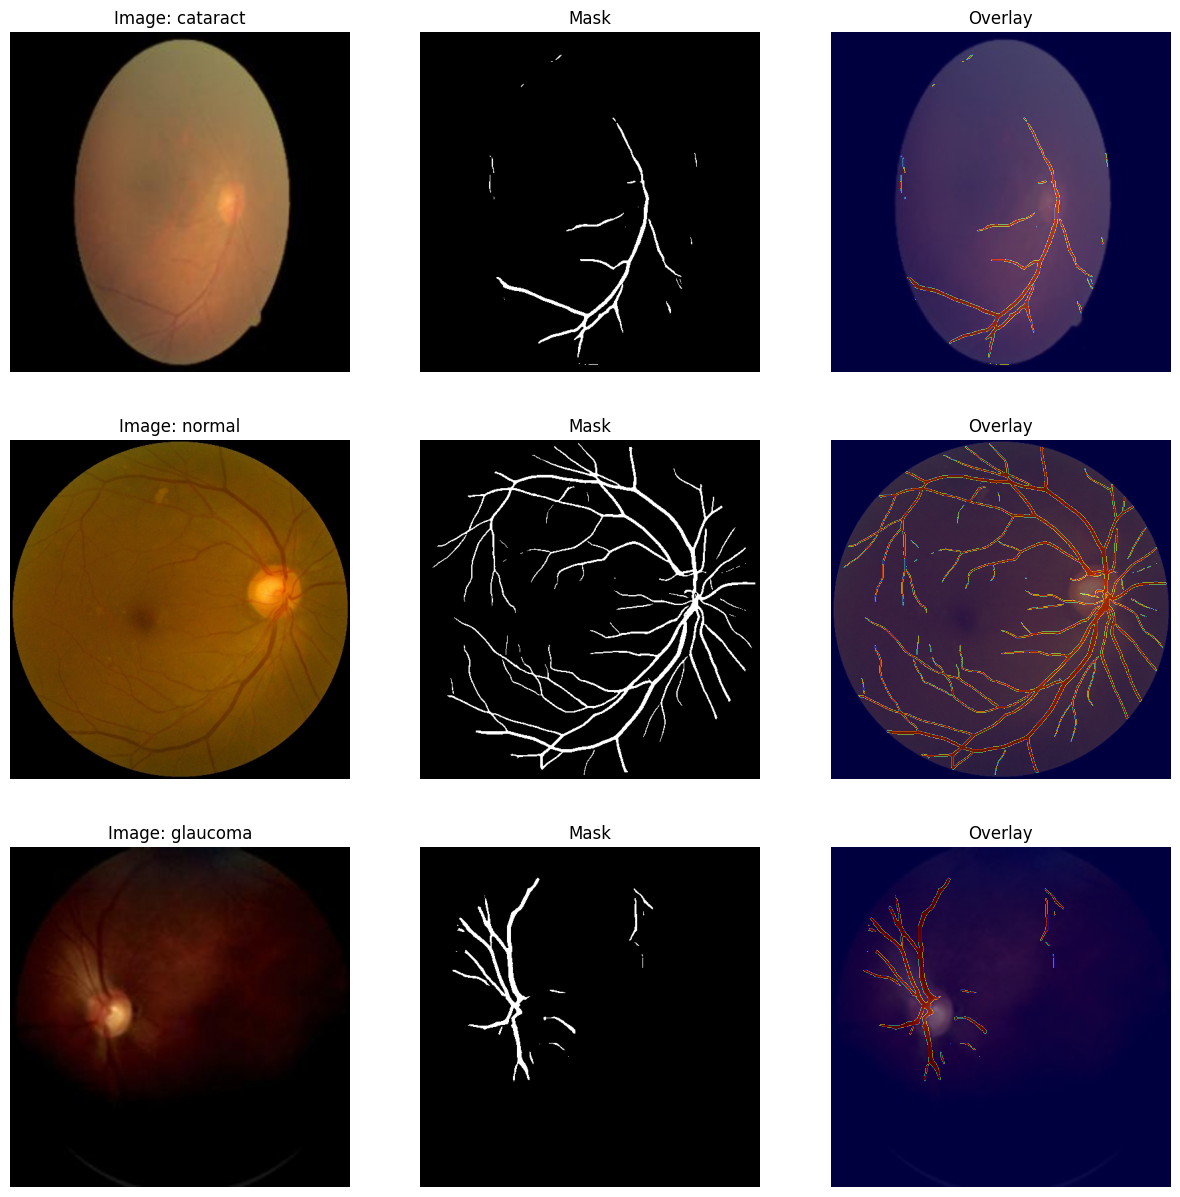

MemoryError: Unable to allocate 24.7 GiB for an array with shape (4217, 512, 512, 3) and data type float64

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau # type: ignore
from tensorflow.keras.applications import ResNet50 # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore

#For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# 1. Data Loading
def load_data(data_dir):
    images = []
    masks = []
    labels = []
    class_names = os.listdir(data_dir)  # Disease folder names

    for class_name in class_names:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        image_dir = os.path.join(class_dir, 'retinal_images')
        mask_dir = os.path.join(class_dir, 'masked_images')

        if not (os.path.isdir(image_dir) and os.path.isdir(mask_dir)):
            print(f"Warning: 'retinal_images' or 'masked_images' directory missing in {class_name}")
            continue

        image_names = os.listdir(image_dir)

        for image_name in image_names:
            image_path = os.path.join(image_dir, image_name)
            # if not os.path.exists(image_path):
            #     image_name = image_name.replace('.jpeg', '.png')
            #     image_path = os.path.join(image_dir, image_name)
            #     if not os.path.exists(image_path):
            #         print(f"Warning: Image not found for {image_name}")
            #         continue
            mask_name = image_name  # Adjust extension if needed
            mask_path = os.path.join(mask_dir, mask_name)

            try:
                image = Image.open(image_path).convert('RGB')
                mask = Image.open(mask_path).convert('L')  # Grayscale for masks
            except FileNotFoundError:
                print(f"Warning: Mask not found for {image_name}")
                continue
            except Exception as e:
                print(f"Error loading {image_name} or its mask: {e}")
                continue

            images.append(np.array(image))
            masks.append(np.array(mask))
            labels.append(class_name)

    return images, masks, labels, class_names

# 2. Data Preprocessing
IMG_WIDTH = 512 # Reduced size for faster training
IMG_HEIGHT = 512

def resize_images(images, masks, width, height):
    resized_images = [cv2.resize(img, (width, height), interpolation=cv2.INTER_AREA) for img in images]
    resized_masks = [cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST) for mask in masks]
    return resized_images, resized_masks

def normalize_images(images):
    return np.array(images) / 255.0

def preprocess_data(images, masks, labels, img_width, img_height):
    resized_images, resized_masks = resize_images(images, masks, img_width, img_height)
    normalized_images = normalize_images(resized_images)
    normalized_masks = normalize_images(resized_masks)

    label_encoder = LabelEncoder()
    integer_encoded_labels = label_encoder.fit_transform(labels)
    num_classes = len(np.unique(integer_encoded_labels))
    one_hot_labels = to_categorical(integer_encoded_labels, num_classes=num_classes)

    return normalized_images, normalized_masks, one_hot_labels, num_classes, label_encoder


def apply_mask_to_images(images, masks):
    binary_masks = (masks > 0.5).astype(np.float32)
    masked_images = images * binary_masks[..., np.newaxis]  # Apply mask to each channel
    return masked_images


# 3. Model Definition (Transfer Learning with ResNet50)
def create_model(num_classes, img_width, img_height):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model


# 4. Training
def train_model(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32, model_name="best_model.h5"):
    checkpoint = ModelCheckpoint(f'models/{model_name}',
                                 monitor='val_loss',
                                 save_best_only=True,
                                 mode='min',
                                 verbose=1)

    early_stopping = EarlyStopping(monitor='val_loss',
                                   patience=5,
                                   restore_best_weights=True,
                                   verbose=1)

    reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                     factor=0.2,
                                     patience=3,
                                     min_lr=1e-6,
                                     verbose=1)

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=[checkpoint, early_stopping, reduce_lr])
    return history

# 5. Evaluation
def evaluate_model(model, X_test, y_test, class_names):
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Loss: {loss:.4f}')
    print(f'Test Accuracy: {accuracy:.4f}')

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


def show_random_images(images, masks, labels, class_names, num_images=3):
    plt.figure(figsize=(15, 5 * num_images))
    for i in range(num_images):
        idx = np.random.randint(0, len(images) - 1)
        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(images[idx])
        plt.title(f"Image: {labels[idx]}")
        plt.axis('off')

        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(masks[idx], cmap='gray')  # Use 'gray' colormap for masks
        plt.title("Mask")
        plt.axis('off')

        # Overlay
        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(images[idx])
        plt.imshow(masks[idx], cmap='jet', alpha=0.5)  # Overlay the mask
        plt.title("Overlay")
        plt.axis('off')
    plt.show()
    # Check if GPU is available and set the device accordingly
    device = '/GPU:0' if tf.config.experimental.list_physical_devices('GPU') else '/CPU:0'
    print(f"Using device: {device}")

    with tf.device(device):
        # 5. Train Model
        history = train_model(model, X_train, y_train, X_val, y_val, epochs=10, batch_size=32, model_name="best_model.h5")
        print("Model Training Complete.")

        # 6. Evaluate Model
        evaluate_model(model, X_test, y_test, class_names)
        print("Model Evaluation Complete.")

# Main Execution
if __name__ == "__main__":
    # 1. Load Data
    data_dir = 'CombinedData'  # Path to your main data directory
    images, masks, labels, class_names = load_data(data_dir)

    print("Data Loading Complete.")
    print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
    print(f"Number of classes: {len(class_names)}")

    # Show some sample images and masks
    show_random_images(images, masks, labels, class_names)
    # 2. Preprocess Data
    normalized_images, normalized_masks, one_hot_labels, num_classes, label_encoder = preprocess_data(
        images, masks, labels, IMG_WIDTH, IMG_HEIGHT)

    # Optional: Apply mask to images
    masked_images = apply_mask_to_images(normalized_images, normalized_masks)

    print("Data Preprocessing Complete.")

    # 3. Split Data
    X_train, X_temp, y_train, y_temp = train_test_split(masked_images, one_hot_labels, test_size=0.3,
                                                        random_state=42, stratify=one_hot_labels)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42,
                                                    stratify=y_temp)  # validation and test from temp

    print("Data Splitting Complete.")

    # 4. Create Model
    model = create_model(num_classes, IMG_WIDTH, IMG_HEIGHT)
    print("Model Creation Complete.")
    model.summary()
